# **DX 799: Week 9 — Gradient Boost**

For this week, include ideas such as gradient boost, learning rate, number of estimators, tree depth, and regularization. This homework should be submitted for peer review in the assignment titled 9.3 Peer Review: Week 9 Jupyter Notebook. Complete and submit your Jupyter Notebook homework by 11:59pm ET on Sunday. 

In [1]:
import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score 
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# Reproducibility
RANDOM_SEED = 42

---

# DIABETES DATASET

In [2]:
#DIABETES: LOAD
df_diabetes = pd.read_csv("../Datasets/diabetes_cleaned.csv")
# The first few rows
df_diabetes.iloc[0:5]

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
y_diabetes = df_diabetes["Diabetes_012"].astype(int)
X_diabetes = df_diabetes.drop(columns=["Diabetes_012"]).select_dtypes("number").astype(np.float32)

cv3_diabetes = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

gb_diabetes = GradientBoostingClassifier(
    random_state=42,
    subsample=0.8,           # regularization
    min_samples_leaf=10,     # regularization
    validation_fraction=0.1, # early stopping
    n_iter_no_change=10,
    tol=1e-4
)

param_grid_diabetes = {
    "learning_rate": [0.05, 0.1],
    "n_estimators": [100, 200],
    "max_depth": [3]
}

gs_diabetes = GridSearchCV(
    gb_diabetes, param_grid_diabetes,
    scoring="accuracy", cv=cv3_diabetes, n_jobs=-1, refit=True
)
gs_diabetes.fit(X_diabetes, y_diabetes)

print("Diabetes — Best params:", gs_diabetes.best_params_)
print(f"Diabetes — Best CV accuracy: {gs_diabetes.best_score_:.4f}")
best_gb_diabetes = gs_diabetes.best_estimator_


Diabetes — Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Diabetes — Best CV accuracy: 0.8496


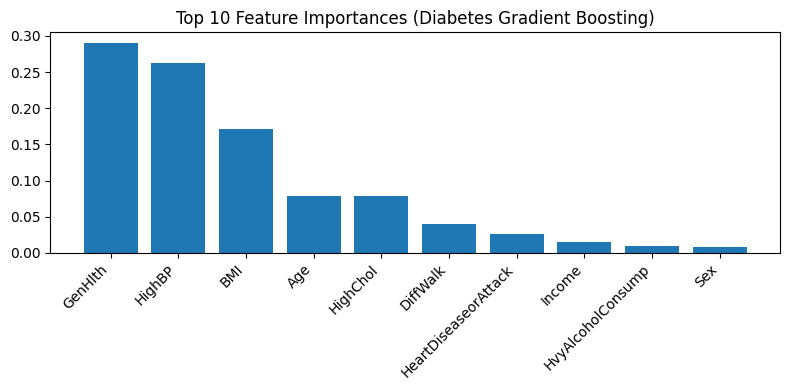

In [4]:
#Plot
best_gb = gs_diabetes.best_estimator_

importances = best_gb.feature_importances_
feat_names = X_diabetes.columns

indices = np.argsort(importances)[::-1][:10]  # top 10
plt.figure(figsize=(8,4))
plt.bar(range(len(indices)), importances[indices], align="center")
plt.xticks(range(len(indices)), feat_names[indices], rotation=45, ha="right")
plt.title("Top 10 Feature Importances (Diabetes Gradient Boosting)")
plt.tight_layout()
plt.show()


---
# KIDNEY DATASET 

In [5]:
#Kidney: LOAD
df_kidney = pd.read_csv("../Datasets/Chronic_Kidney_Dsease_data.csv")
# The first few rows
df_kidney.iloc[0:5]

,PatientID,Age,Gender,Ethnicity,SocioeconomicStatus,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryKidneyDisease,FamilyHistoryHypertension,FamilyHistoryDiabetes,PreviousAcuteKidneyInjury,UrinaryTractInfections,SystolicBP,DiastolicBP,FastingBloodSugar,HbA1c,SerumCreatinine,BUNLevels,GFR,ProteinInUrine,ACR,SerumElectrolytesSodium,SerumElectrolytesPotassium,SerumElectrolytesCalcium,SerumElectrolytesPhosphorus,HemoglobinLevels,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,ACEInhibitors,Diuretics,NSAIDsUse,Statins,AntidiabeticMedications,Edema,FatigueLevels,NauseaVomiting,MuscleCramps,Itching,QualityOfLifeScore,HeavyMetalsExposure,OccupationalExposureChemicals,WaterQuality,MedicalCheckupsFrequency,MedicationAdherence,HealthLiteracy,Diagnosis,DoctorInCharge
0,1,71,0,0,0,2,31.069414,1,5.128112,1.676220,0.240386,4.076434,0,0,0,0,0,113,83,72.510788,9.212397,4.962531,25.605949,45.703204,0.744980,123.849426,137.652501,3.626058,10.314420,3.152648,16.114679,207.728670,85.863656,21.967957,212.095215,0,0,4.563139,1,0,0,3.563894,6.992244,4.518513,7.556302,76.076800,0,0,1,1.018824,4.966808,9.871449,1,Confidential
1,2,34,0,0,1,3,29.692119,1,18.609552,8.377574,6.503233,7.652813,1,1,0,0,0,120,67,100.848875,4.604989,3.156799,31.338166,55.784504,3.052317,88.539095,138.141335,5.332871,9.604196,2.855443,15.349205,189.450727,86.378670,87.569756,255.451314,0,0,9.097002,0,0,0,5.327336,0.356290,2.202222,6.836766,40.128498,0,0,0,3.923538,8.189275,7.161765,1,Confidential
2,3,80,1,1,0,1,37.394822,1,11.882429,9.607401,2.104828,4.392786,0,0,0,0,0,147,106,160.989441,5.432599,3.698236,39.738169,67.559032,1.157839,21.170892,142.970116,4.330891,9.885786,4.353513,13.018834,284.137622,132.269872,20.049798,251.902583,0,1,3.851249,1,0,0,4.855420,4.674069,5.967271,2.144722,92.872842,0,1,1,1.429906,7.624028,7.354632,1,Confidential
3,4,40,0,2,0,1,31.329680,0,16.020165,0.408871,6.964422,6.282274,0,0,0,0,0,117,65,188.506620,4.144466,2.868468,21.980958,33.202542,3.745871,123.779699,137.106913,3.810741,9.995894,4.016134,15.056339,235.112124,93.443669,58.260291,392.338425,0,0,7.881765,0,0,0,8.531685,5.691455,2.176387,7.077188,90.080321,0,0,0,3.226416,3.282688,6.629587,1,Confidential
4,5,43,0,1,1,2,23.726311,0,7.944146,0.780319,3.097796,4.021639,0,0,0,0,0,98,66,82.156699,4.262979,3.964877,12.216366,56.319082,2.570993,184.852046,140.627812,4.866765,8.907622,3.947907,16.690561,258.277566,171.758356,21.583213,370.523877,1,1,4.179459,1,0,0,1.422320,2.273459,6.800993,3.553118,5.258372,0,0,1,0.285466,3.849498,1.437385,1,Confidential


In [6]:
y_kidney = df_kidney["Diagnosis"].astype(int)
X_kidney = df_kidney.drop(columns=["Diagnosis", "DoctorInCharge"], errors="ignore") \
                    .select_dtypes("number").astype(np.float32)

cv3_kidney = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

gb_kidney = GradientBoostingClassifier(
    random_state=42,
    subsample=0.8,
    min_samples_leaf=10,
    validation_fraction=0.1,
    n_iter_no_change=10,
    tol=1e-4
)

param_grid_kidney = {
    "learning_rate": [0.05, 0.1],
    "n_estimators": [100, 200],
    "max_depth": [3]
}

gs_kidney = GridSearchCV(
    gb_kidney, param_grid_kidney,
    scoring="accuracy", cv=cv3_kidney, n_jobs=-1, refit=True
)
gs_kidney.fit(X_kidney, y_kidney)

print("Kidney — Best params:", gs_kidney.best_params_)
print(f"Kidney — Best CV accuracy: {gs_kidney.best_score_:.4f}")
best_gb_kidney = gs_kidney.best_estimator_



Kidney — Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Kidney — Best CV accuracy: 0.9271


---

# HYPERTENSION DATASET

In [7]:
#HYPERTENSION: LOAD
df_hypertension = pd.read_csv("../Datasets/df_hypertension_clean.csv")
# The first few rows
df_hypertension.iloc[0:5]

,Country,Age,BMI,Cholesterol,Systolic_BP,Diastolic_BP,Smoking_Status,Alcohol_Intake,Physical_Activity_Level,Family_History,Diabetes,Stress_Level,Salt_Intake,Sleep_Duration,Heart_Rate,LDL,HDL,Triglycerides,Glucose,Gender,Education_Level,Employment_Status,Hypertension
0,UK,58,29.5,230,160,79,Never,27.9,Low,1,1,9,14.7,6.1,80,100,75,72,179,Female,Primary,Unemployed,1
1,Spain,34,36.2,201,120,84,Never,27.5,High,1,1,6,10.8,9.8,56,77,47,90,113,Male,Secondary,Unemployed,1
2,Indonesia,73,18.2,173,156,60,Current,1.8,High,1,1,5,6.5,5.2,75,162,56,81,101,Male,Primary,Employed,0
3,Canada,60,20.3,183,122,94,Never,11.6,Moderate,1,1,6,4.0,7.5,71,164,93,94,199,Female,Secondary,Retired,1
4,France,73,21.8,296,91,97,Never,29.1,Moderate,1,0,6,8.4,5.0,52,108,74,226,157,Female,Primary,Employed,1


In [8]:
obj_cols = df_hypertension.select_dtypes(include="object").columns.tolist()
df_hyp_enc = pd.get_dummies(df_hypertension, columns=obj_cols, drop_first=True)

In [9]:
# X, y
y_hypertension = df_hyp_enc["Hypertension"].astype(int)
X_hypertension = df_hyp_enc.drop(columns=["Hypertension", "Systolic_BP"], errors="ignore") \
                                       .select_dtypes("number").astype(np.float32)

cv3_hyp = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

gb_hyp = GradientBoostingClassifier(
    random_state=42,
    subsample=0.8,
    min_samples_leaf=10,
    validation_fraction=0.1,
    n_iter_no_change=10,
    tol=1e-4
)

param_grid_hyp = {
    "learning_rate": [0.05, 0.1],
    "n_estimators": [100, 200],
    "max_depth": [3]
}

gs_hyp = GridSearchCV(
    gb_hyp, param_grid_hyp,
    scoring="accuracy", cv=cv3_hyp, n_jobs=-1, refit=True
)
gs_hyp.fit(X_hypertension, y_hypertension)

print("Hypertension — Best params:", gs_hyp.best_params_)
print(f"Hypertension — Best CV accuracy: {gs_hyp.best_score_:.4f}")
best_gb_hyp = gs_hyp.best_estimator_

Hypertension — Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Hypertension — Best CV accuracy: 0.7188
